# Dharwad Dataset Evaluation - Soil Moisture Retrieval

This notebook evaluates the pretrained global Random Forest (RF) and Artificial Neural Network (ANN) models on the Dharwad dataset.

In [1]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import mean_squared_error, r2_score

# Paths
base_dir = os.path.abspath('..')
raw_data_path = os.path.join(base_dir, 'data', 'Raw', 'Dharwad_Soil_Moisture.csv')
models_dir = os.path.join(base_dir, 'models')
rf_model_path = os.path.join(models_dir, 'rf_global_model.pkl')
ann_model_path = os.path.join(models_dir, 'ann_global_model.keras')
scaler_path = os.path.join(models_dir, 'global_scaler.pkl')

print("Loading dataset...")
df = pd.read_csv(raw_data_path)

def extract_coords(geo_str):
    try:
        coords = json.loads(geo_str)['coordinates']
        return coords[1], coords[0]   # lat, lon
    except:
        return np.nan, np.nan

print("Preprocessing...")
df[['lat', 'lon']] = pd.DataFrame(df['.geo'].apply(extract_coords).tolist(), index=df.index)
df['VV_VH_ratio'] = df['VV'] / (df['VH'] + 1e-6)
df['NDVI_VV'] = df['NDVI'] * df['VV']
df['SAR_Index'] = (df['VV'] - df['VH']) / (df['VV'] + df['VH'] + 1e-6)
df['VV_VH_diff'] = df['VV'] - df['VH']
df['VV_VH_sum'] = df['VV'] + df['VH']
df['NDVI_VH'] = df['NDVI'] * df['VH']
df['month'] = 0
df['DOY'] = 0

features = ['VV', 'VH', 'NDVI', 'VV_VH_ratio', 'NDVI_VV', 'month', 'DOY', 'lat', 'lon', 'SAR_Index', 'VV_VH_diff', 'VV_VH_sum', 'NDVI_VH']
scaler = joblib.load(scaler_path)
X = scaler.transform(df[features])
y = df['soil_moisture'].values

print(f"Data ready. Samples: {len(df)}")

Loading dataset...
Preprocessing...
Data ready. Samples: 322


## 1. Random Forest Evaluation

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


RF RMSE: 0.0070
RF R2 Score: -2.8517


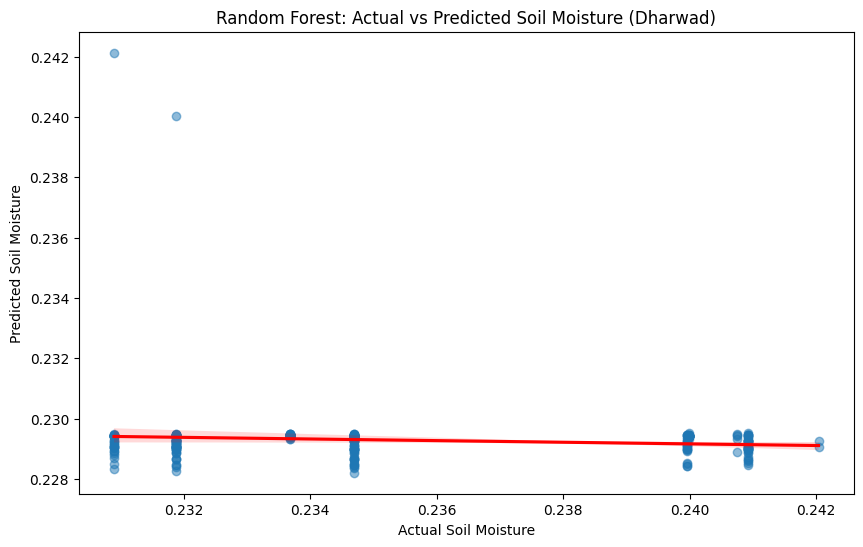

In [2]:
rf_model = joblib.load(rf_model_path)
y_pred_rf = rf_model.predict(X)

rmse_rf = np.sqrt(mean_squared_error(y, y_pred_rf))
r2_rf = r2_score(y, y_pred_rf)

print(f"RF RMSE: {rmse_rf:.4f}")
print(f"RF R2 Score: {r2_rf:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x=y, y=y_pred_rf, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title("Random Forest: Actual vs Predicted Soil Moisture (Dharwad)")
plt.xlabel("Actual Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.show()

## 2. Artificial Neural Network (ANN) Evaluation

ANN RMSE: 0.0293
ANN R2 Score: -65.8976


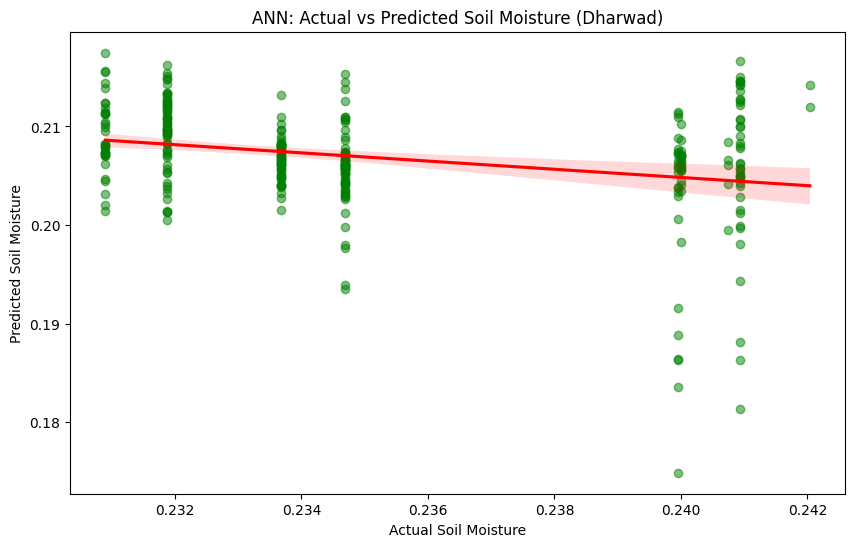

In [3]:
ann_model = tf.keras.models.load_model(ann_model_path)
y_pred_ann = ann_model.predict(X, verbose=0).flatten()

rmse_ann = np.sqrt(mean_squared_error(y, y_pred_ann))
r2_ann = r2_score(y, y_pred_ann)

print(f"ANN RMSE: {rmse_ann:.4f}")
print(f"ANN R2 Score: {r2_ann:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x=y, y=y_pred_ann, scatter_kws={'alpha': 0.5, 'color': 'green'}, line_kws={'color': 'red'})
plt.title("ANN: Actual vs Predicted Soil Moisture (Dharwad)")
plt.xlabel("Actual Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.show()

## 3. Residual Analysis Comparison

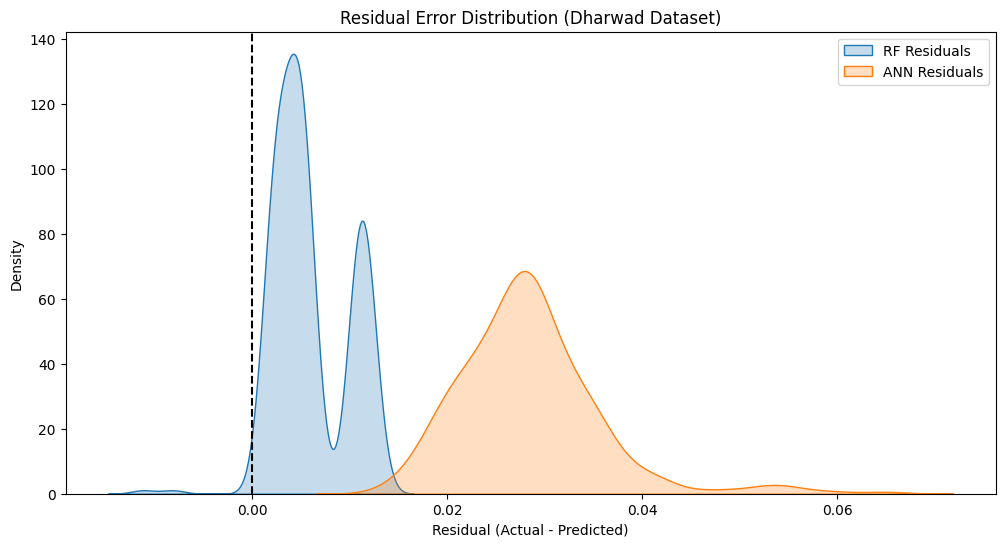

In [4]:
res_rf = y - y_pred_rf
res_ann = y - y_pred_ann

plt.figure(figsize=(12, 6))
sns.kdeplot(res_rf, label="RF Residuals", fill=True)
sns.kdeplot(res_ann, label="ANN Residuals", fill=True)
plt.axvline(0, color='black', linestyle='--')
plt.title("Residual Error Distribution (Dharwad Dataset)")
plt.xlabel("Residual (Actual - Predicted)")
plt.legend()
plt.show()